   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


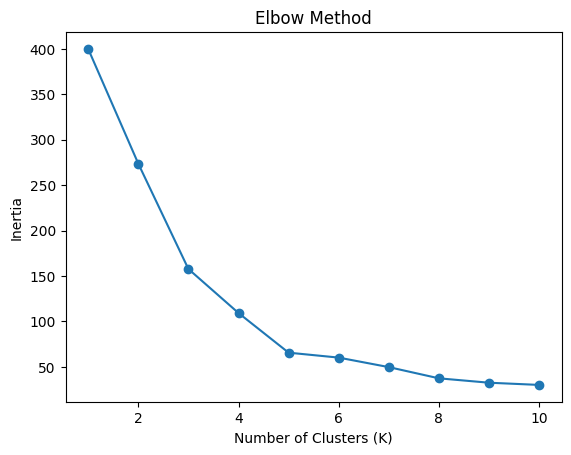


Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


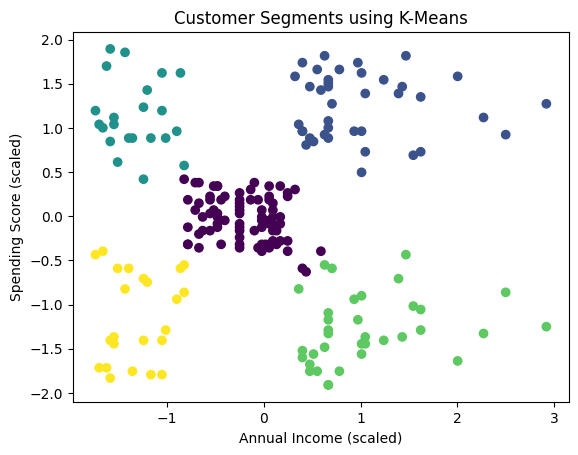

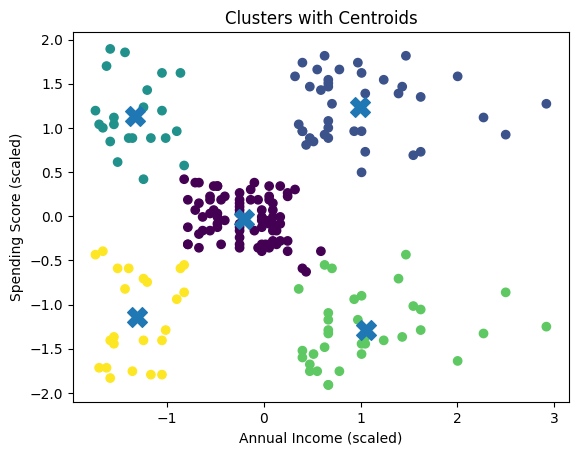


Cluster Analysis:
          Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043

Cluster Counts:
 Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

data = pd.read_csv("Mall_Customers.csv")
print(data.head())
print("\nMissing Values:\n", data.isnull().sum())
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

data['Cluster'] = clusters
print("\nInertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, clusters))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Customer Segments using K-Means")
plt.show()

centroids = kmeans.cluster_centers_
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200)
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Clusters with Centroids")
plt.show()
cluster_analysis = data.groupby('Cluster')[
    ['Annual Income (k$)', 'Spending Score (1-100)']
].mean()
print("\nCluster Analysis:\n", cluster_analysis)
print("\nCluster Counts:\n", data['Cluster'].value_counts())

Log Likelihood: -2.2625026219732405
AIC: 963.0010487892962
BIC: 1058.6522524191892
Silhouette Score: 0.5536892843811245


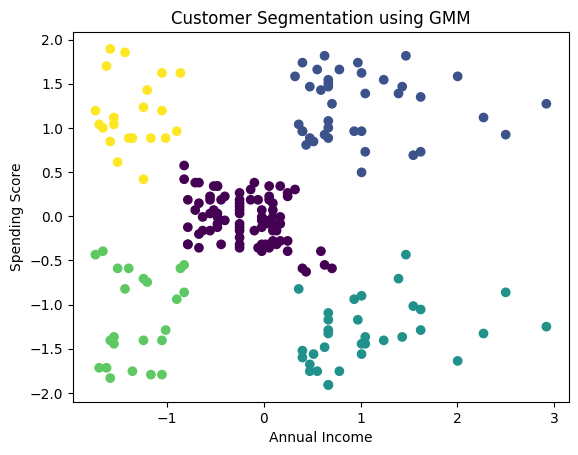

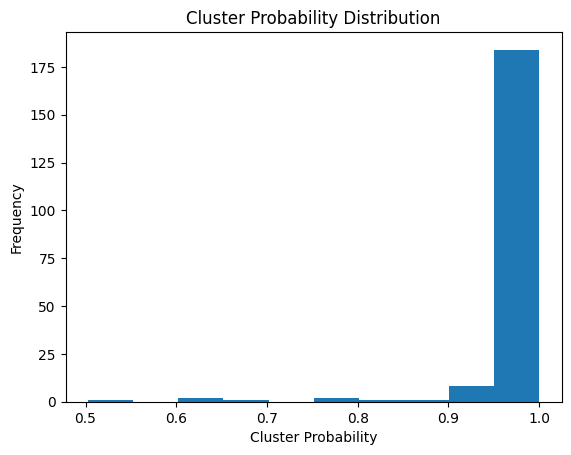

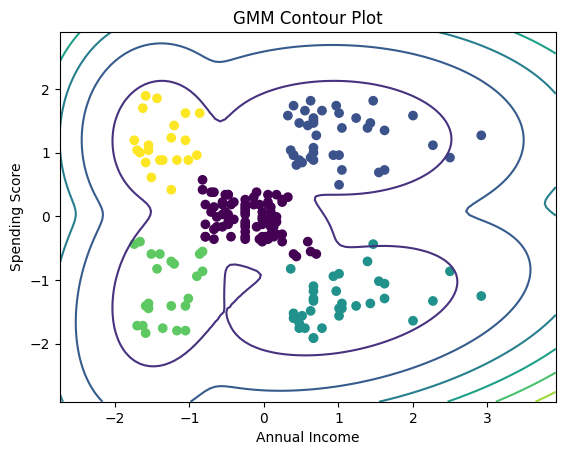

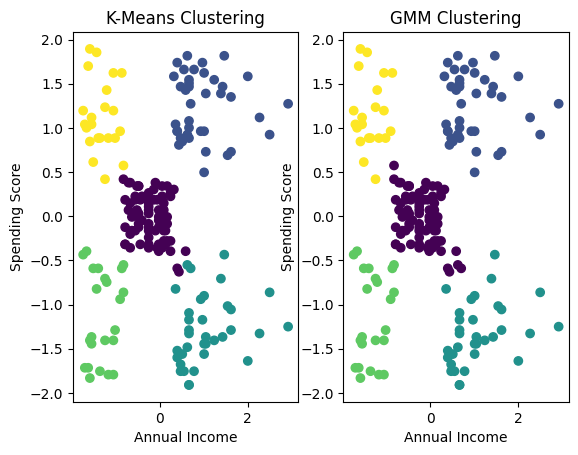

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

data = pd.read_csv("Mall_Customers.csv")
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
gmm = GaussianMixture(n_components=5, random_state=0)
gmm.fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)

probabilities = gmm.predict_proba(X_scaled)
print("Log Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))

sil_score = silhouette_score(X_scaled, gmm_labels)
print("Silhouette Score:", sil_score)
plt.figure()
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=gmm_labels)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using GMM")
plt.show()

plt.figure()
plt.hist(probabilities.max(axis=1), bins=10)
plt.xlabel("Cluster Probability")
plt.ylabel("Frequency")
plt.title("Cluster Probability Distribution")
plt.show()

x = np.linspace(X_scaled[:,0].min()-1, X_scaled[:,0].max()+1, 100)
y = np.linspace(X_scaled[:,1].min()-1, X_scaled[:,1].max()+1, 100)

X_grid, Y_grid = np.meshgrid(x, y)
grid = np.array([X_grid.ravel(), Y_grid.ravel()]).T

Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)

plt.figure()
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=gmm_labels)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("GMM Contour Plot")
plt.show()

kmeans = KMeans(n_clusters=5, random_state=0)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.figure()
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=gmm_labels)
plt.title("GMM Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()